### 给用户推荐电影
 
$n_m$：电影数量  
$n_u$：用户数量  
$y^{(i,j)}$：用户j对电影i的评分  
$r^{(i,j)}$：用户j是否对电影i做出评分  

$X(n_m,n_f)$：电影的特征  
$\theta(n_u,n_f)$：用户的特征

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [2]:
mat=sio.loadmat('data/ex8_movies.mat')
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Y', 'R'])

In [3]:
Y,R=mat['Y'],mat['R']
Y.shape,R.shape

((1682, 943), (1682, 943))

In [4]:
param_mat=sio.loadmat('data/ex8_movieParams.mat')
param_mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'Theta', 'num_users', 'num_movies', 'num_features'])

In [5]:
X,Theta,nu,nm,nf=param_mat['X'],param_mat['Theta'],param_mat['num_users'],param_mat['num_movies'],param_mat['num_features']

In [6]:
X.shape,Theta.shape,nu,nm,nf

((1682, 10),
 (943, 10),
 array([[943]], dtype=uint16),
 array([[1682]], dtype=uint16),
 array([[10]], dtype=uint8))

In [7]:
nu=int(nu)
nm=int(nm)
nf=int(nf)
nu,nm,nf

C:\Users\cqy\AppData\Local\Temp\ipykernel_40796\2153360960.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nu=int(nu)
C:\Users\cqy\AppData\Local\Temp\ipykernel_40796\2153360960.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nm=int(nm)
C:\Users\cqy\AppData\Local\Temp\ipykernel_40796\2153360960.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nf=int(nf)


(943, 1682, 10)

#### 1.序列化参数

In [8]:
def serialize(X,Theta):
    return np.append(X.flatten(),Theta.flatten())

#### 2.解序列化参数

In [9]:
def deserialize(params,nm,nu,nf):
    X=params[:nm*nf].reshape(nm,nf)
    Theta=params[nm*nf:].reshape(nu,nf)
    return X,Theta

#### 3.代价函数

$Y=X@Theta.T$

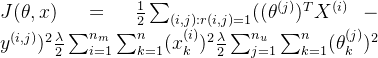

In [15]:
def costFunction(params,Y,R,nm,nu,nf,lamda):
    X,Theta=deserialize(params,nm,nu,nf)
    error=0.5*np.square((X@Theta.T-Y)*R).sum()
    reg1=0.5*lamda*np.square(X).sum()
    reg2=0.5*lamda*np.square(Theta).sum()
    return error+reg1+reg2

In [16]:
users=4
movies=5
features=3
X_sub=X[:movies,:features]
Theta_sub=Theta[:users,:features]
Y_sub=Y[:movies,:users]
R_sub=R[:movies,:users]
cost1=costFunction(serialize(X_sub,Theta_sub),Y_sub,R_sub,movies,users,features,lamda=0)
print(cost1)

22.224603725685675


In [17]:
cost2=costFunction(serialize(X_sub,Theta_sub),Y_sub,R_sub,movies,users,features,lamda=1.5)
print(cost2)

31.344056244274217


#### 4.梯度

In [18]:
def costGradient(params,Y,R,nm,nu,nf,lamda):
    X,Theta=deserialize(params,nm,nu,nf)
    X_grad=((X@Theta.T-Y)*R)@Theta+lamda*X
    Theta_grad=((X@Theta.T-Y)*R).T@X+lamda*Theta
    return serialize(X_grad,Theta_grad)

#### 5.添加新用户

In [19]:
my_ratings = np.zeros((nm, 1))
 
# 添加电影评分
my_ratings[9] = 5
my_ratings[66] = 5
my_ratings[96] = 5
my_ratings[121] = 4
my_ratings[148] = 4
my_ratings[285] = 3
my_ratings[490] = 4
my_ratings[599] = 4
my_ratings[643] = 4
my_ratings[958] = 5
my_ratings[1117] = 3

In [20]:
Y=np.c_[Y,my_ratings]
R=np.c_[R,my_ratings!=0]

In [21]:
nm,nu=Y.shape

#### 6.均值归一化

In [29]:
def normalizeRatings(Y,R):
    Y_mean=(Y.sum(axis=1)/R.sum(axis=1)).reshape(-1,1)
    Y_norm=(Y-Y_mean)*R
    return Y_norm,Y_mean

In [33]:
Y_norm,Y_mean=normalizeRatings(Y,R)

#### 7.参数初始化

In [24]:
X=np.random.random((nm,nf))
Theta=np.random.random((nu,nf))
params=serialize(X,Theta)
lamda=5

#### 8.模型训练

In [26]:
from scipy.optimize import minimize
res=minimize(fun=costFunction,
        x0=params,
        args=(Y_norm,R,nm,nu,nf,lamda),
        method='TNC',
        jac=costGradient,
        options={'maxiter':100})

C:\Users\cqy\AppData\Local\Temp\ipykernel_40796\2452807771.py:2: OptimizeWarning: Unknown solver options: maxiter
  res=minimize(fun=costFunction,


In [27]:
params_fit=res.x

In [30]:
fit_X,fit_Theta=deserialize(params_fit,nm,nu,nf)

#### 9.预测

In [31]:
Y_pred=fit_X@fit_Theta.T

In [34]:
y_pred=Y_pred[:,-1]+Y_mean.flatten()

In [35]:
index=np.argsort(-y_pred)

In [36]:
index[:10]

array([1535, 1499, 1598, 1121,  813, 1466, 1200, 1188, 1652, 1292])

In [37]:
movies=[]
with open('data/movie_ids.txt','r',encoding='latin 1') as f:
    for line in f:
        tokens=line.strip().split(' ')
        movies.append(''.join(tokens[1:]))

In [38]:
for i in range(10):
    print(index[i],movies[index[i]],y_pred[index[i]])

1535 Aiqingwansui(1994) 5.000000000622733
1499 SantawithMuscles(1996) 5.000000000063425
1598 SomeoneElse'sAmerica(1995) 5.00000000004425
1121 TheyMadeMeaCriminal(1939) 5.0000000000206315
813 GreatDayinHarlem,A(1994) 4.999999999995933
1466 SaintofFortWashington,The(1993) 4.999999999995651
1200 MarleneDietrich:ShadowandLight(1996) 4.999999999995157
1188 Prefontaine(1997) 4.999999999990616
1652 EntertainingAngels:TheDorothyDayStory(1996) 4.9999999999862
1292 StarKid(1997) 4.9999999999307425
